# JupyterLite examples

## Matplotlib

In [1]:
import numpy as np
import matplotlib.pyplot as plt

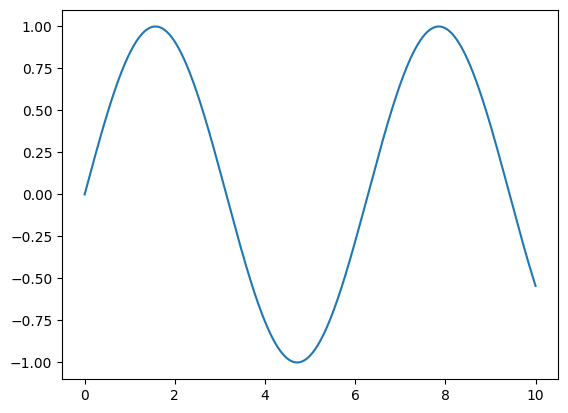

In [2]:
x = np.linspace(0, 10, 1000)
plt.plot(x, np.sin(x));

In [3]:
plt.show()

## Matplotlib: support for widgets backend

In [4]:
import sys
if "pyodide" in sys.modules:
    import piplite

    await piplite.install("ipympl")

In [5]:
# Enable the widget backend
# %matplotlib widget

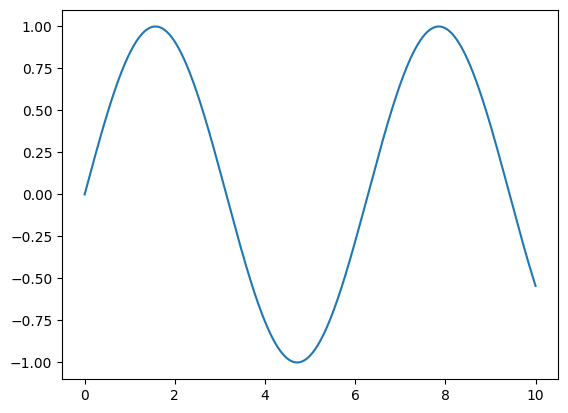

In [6]:
x = np.linspace(0, 10, 1000)
plt.plot(x, np.sin(x))

## Numpy with matplotlib

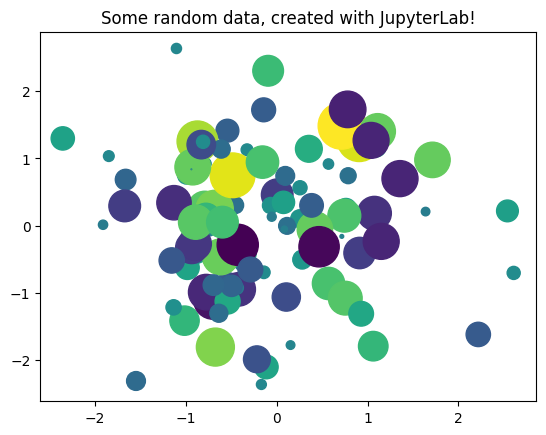

In [7]:
import numpy as np
from matplotlib import pyplot as plt

x, y, scale = np.random.randn(3, 100)
fig, ax = plt.subplots()

ax.scatter(x=x, y=y, c=scale, s=np.abs(scale) * 500)
ax.set(title="Some random data, created with JupyterLab!")
plt.show()

## Plotly in JupyterLite

`plotly.py` is an interactive, open-source, and browser-based graphing library for Python: https://plotly.com/python/

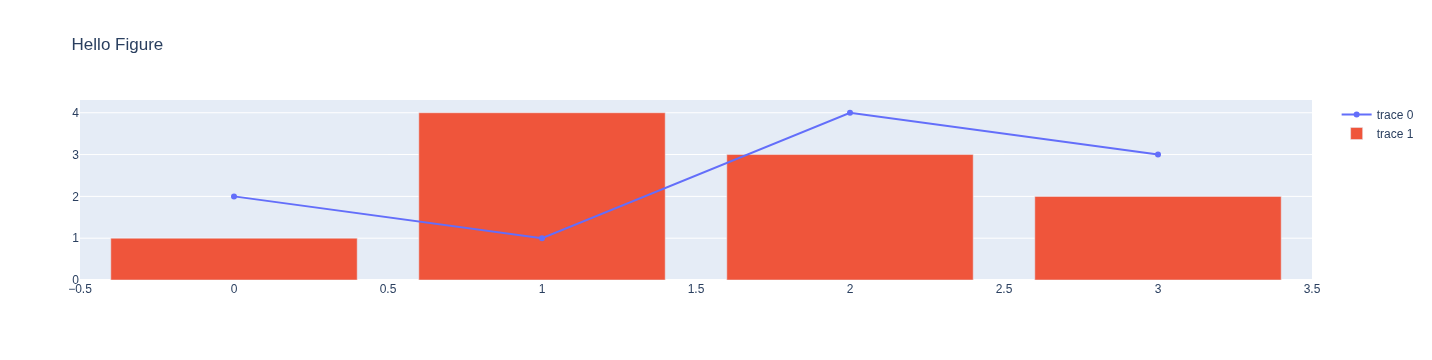

In [8]:
import plotly.graph_objects as go
fig = go.Figure()
fig.add_trace(go.Scatter(y=[2, 1, 4, 3]))
fig.add_trace(go.Bar(y=[1, 4, 3, 2]))
fig.update_layout(title = 'Hello Figure')
fig.show()

## Pandas DataFrame

In [9]:
import pandas as pd
import numpy as np
from string import ascii_uppercase as letters
from IPython.display import display

df = pd.DataFrame(np.random.randint(0, 100, size=(100, len(letters))), columns=list(letters))
df

,A,B,C,D,E,F,G,H,I,J,...,Q,R,S,T,U,V,W,X,Y,Z
0,76,54,65,34,23,48,82,62,54,37,...,61,16,70,8,93,13,2,53,83,57
1,81,14,29,52,17,8,44,8,86,33,...,43,72,4,21,58,78,83,97,88,21
2,20,23,52,18,45,75,45,10,14,29,...,28,37,47,31,70,35,96,30,17,51
3,45,23,45,26,74,96,26,45,6,79,...,47,31,21,95,23,82,78,39,86,14
4,71,57,19,72,93,51,89,18,17,17,...,75,59,25,8,71,63,29,42,85,74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,10,3,99,30,49,82,24,0,75,66,...,98,11,32,75,65,75,97,55,30,69
96,29,96,64,54,35,64,55,79,41,8,...,57,77,80,29,43,6,38,16,50,74
97,37,19,74,40,69,18,20,4,92,26,...,30,92,71,64,4,52,9,61,48,76
98,88,71,43,69,72,53,45,74,87,24,...,99,68,75,34,9,64,4,54,51,31


## Pandas with Plotly

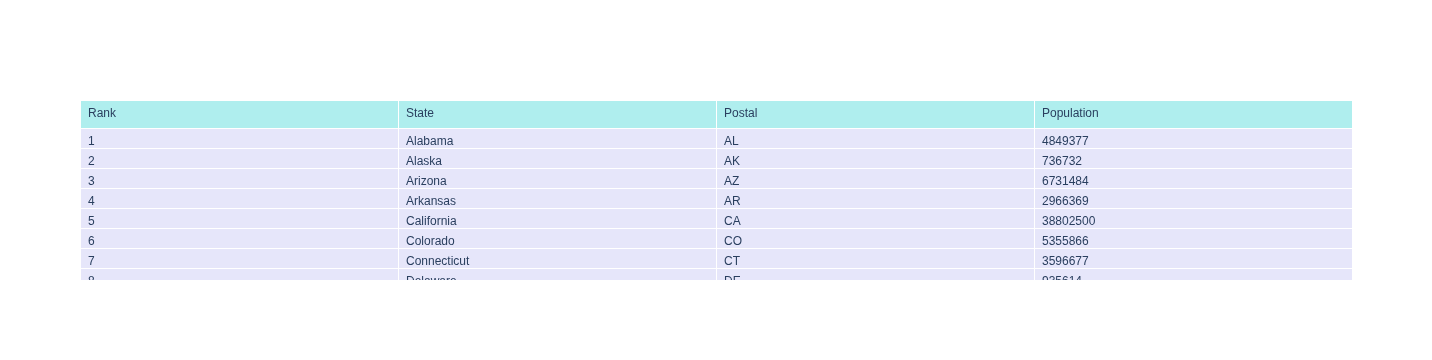

In [10]:
import plotly.graph_objects as go
import pandas as pd
from pathlib import Path
import requests


dest = None
for input_usa in (
    Path("data/2014_usa_states.csv"),
    Path("jupyter/book/data/2014_usa_states.csv"),
):
    try:
        with input_use.open("rb"):
            data_usa = input_usa
            break
    except OSError:
        pass

df = pd.read_csv(data_usa)

fig = go.Figure(data=[go.Table(
    header=dict(values=list(df.columns),
                fill_color='paleturquoise',
                align='left'),
    cells=dict(values=[df.Rank, df.State, df.Postal, df.Population],
               fill_color='lavender',
               align='left'))
])

fig.show()

## Quiver Plot with Points in Plotly

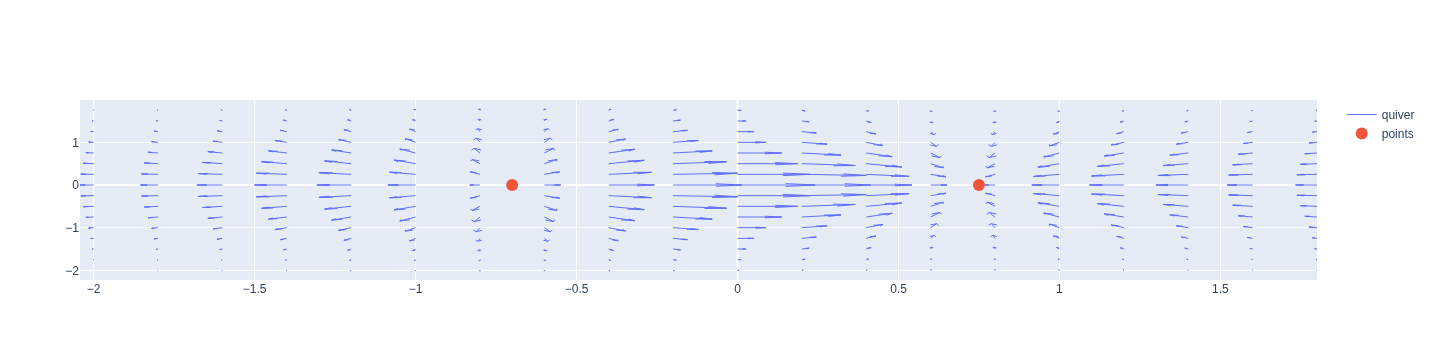

In [11]:
import plotly.figure_factory as ff
import plotly.graph_objects as go

import numpy as np

x,y = np.meshgrid(np.arange(-2, 2, .2),
                  np.arange(-2, 2, .25))
z = x*np.exp(-x**2 - y**2)
v, u = np.gradient(z, .2, .2)

# Create quiver figure
fig = ff.create_quiver(x, y, u, v,
                       scale=.25,
                       arrow_scale=.4,
                       name='quiver',
                       line_width=1)

# Add points to figure
fig.add_trace(go.Scatter(x=[-.7, .75], y=[0,0],
                    mode='markers',
                    marker_size=12,
                    name='points'))

fig.show()

## Altair

**Altair** is a declarative statistical visualization library for Python.

Most of the examples below are from: https://altair-viz.github.io/gallery

### Simple Bar Chart

In [12]:
import altair as alt
import pandas as pd

source = pd.DataFrame({
    'a': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I'],
    'b': [28, 55, 43, 91, 81, 53, 19, 87, 52]
})

alt.Chart(source).mark_bar().encode(
    x='a',
    y='b'
)

alt.Chart(...)

### Simple Heatmap

In [13]:
import altair as alt
import numpy as np
import pandas as pd

# Compute x^2 + y^2 across a 2D grid
x, y = np.meshgrid(range(-5, 5), range(-5, 5))
z = x ** 2 + y ** 2

# Convert this grid to columnar data expected by Altair
source = pd.DataFrame({'x': x.ravel(),
                     'y': y.ravel(),
                     'z': z.ravel()})

alt.Chart(source).mark_rect().encode(
    x='x:O',
    y='y:O',
    color='z:Q'
)


alt.Chart(...)

### Install the Vega Dataset

In [14]:
import sys
if "pyodide" in sys.modules:
    import piplite

    await piplite.install("vega_datasets")

### Interactive Average

In [15]:
import altair as alt
from vega_datasets import data

source = data.seattle_weather()
brush = alt.selection_interval(encodings=['x'])

bars = alt.Chart().mark_bar().encode(
    x='month(date):O',
    y='mean(precipitation):Q',
    opacity=alt.condition(brush, alt.OpacityValue(1), alt.OpacityValue(0.7)),
).add_params(
    brush
)

line = alt.Chart().mark_rule(color='firebrick').encode(
    y='mean(precipitation):Q',
    size=alt.SizeValue(3)
).transform_filter(
    brush
)

alt.layer(bars, line, data=source)

alt.LayerChart(...)

### Locations of US Airports

In [16]:
import altair as alt
from vega_datasets import data

airports = data.airports.url
states = alt.topo_feature(data.us_10m.url, feature='states')

# US states background
background = alt.Chart(states).mark_geoshape(
    fill='lightgray',
    stroke='white'
).properties(
    width=500,
    height=300
).project('albersUsa')

# airport positions on background
points = alt.Chart(airports).transform_aggregate(
    latitude='mean(latitude)',
    longitude='mean(longitude)',
    count='count()',
    groupby=['state']
).mark_circle().encode(
    longitude='longitude:Q',
    latitude='latitude:Q',
    size=alt.Size('count:Q', title='Number of Airports'),
    color=alt.value('steelblue'),
    tooltip=['state:N','count:Q']
).properties(
    title='Number of airports in US'
)

background + points


alt.LayerChart(...)